# SDE vs. SGD Model Comparison

---

Stochastic Gradient Descent (SGD) is a simple yet very efficient approach to fitting linear classifiers and regressors under convex loss functions such as (linear) SVMs and Logistic Regression classification models. For our experiment, our SGD model is derived as a **Stochastic Differential Equation**, which is a mathematical model for simulating the dynamics of Brownian motion, an important concept that provides the framework for stochastic gradient descent models. The equation is given below:

$$d\theta_t = -\nabla L(\theta_t) dt + \sqrt{2\gamma B(\theta_t)} dW_t$$

where:
- $L(\theta)$ is the loss function
- $B(\theta)$ is the noise covariance tensor
- $\gamma$ is a noise scale parameter
- $W_t$ is a standard Wiener process

We cannot use standard calculus techniques to solve the SDE as stochastic differential equations are not continuous due to the $W_t$ term. In order to do that, we must resort to more advanced numerical methods to model it accordingly.

First, let's implement the necessary libraries. We will be using the following:

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor
from sklearn.linear_model import SGDClassifier
from sklearn.pipeline import Pipeline
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST

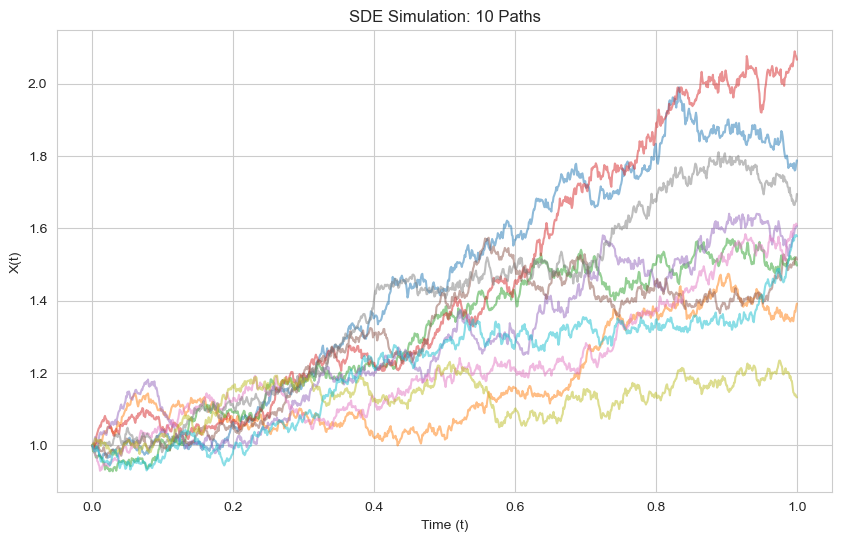

In [4]:
# From src/models/sde_simulator.py, we will implement our code here:

class SDESimulator:
    def __init__(self, drift_func, diffusion_func, paths, points, T=1.0, X0=0.0):
        """
        Initializes the SDE simulator (dX = drift*dt + diffusion*dW).
        """
        self.drift_func = drift_func
        self.diffusion_func = diffusion_func
        self.paths = paths
        self.points = points
        self.T = T
        self.X0 = X0
        self.dt = T / (points - 1)
        self.t_axis = np.linspace(0, T, points)

    def simulate(self):
        """Simulates paths using Euler-Maruyama method."""
        X = np.zeros((self.paths, self.points))
        X[:, 0] = self.X0
        
        # Standard normal random variables for Weiner process
        dW = np.random.normal(0, np.sqrt(self.dt), (self.paths, self.points - 1))
        
        for i in range(self.points - 1):
            X[:, i+1] = X[:, i] + \
                        self.drift_func(X[:, i], self.t_axis[i]) * self.dt + \
                        self.diffusion_func(X[:, i], self.t_axis[i]) * dW[:, i]
        return X

    def plot_paths(self, X):
        """Plots simulation paths."""
        plt.figure(figsize=(10, 6))
        sns.set_style("whitegrid")
        plt.plot(self.t_axis, X.T, alpha=0.5)
        plt.title(f"SDE Simulation: {self.paths} Paths")
        plt.xlabel("Time (t)")
        plt.ylabel("X(t)")
        plt.show()

# --- Test Case ---
if __name__ == '__main__':
    # Example: Geometric Brownian Motion (drift_func=mu*x, diff_func=sigma*x)
    mu, sigma = 0.5, 0.2
    
    # Define SDE functions
    drift = lambda x, t: mu * x
    diffusion = lambda x, t: sigma * x
    
    # Run simulation
    sim = SDESimulator(drift, diffusion, paths=10, points=1000, T=1.0, X0=1.0)
    X = sim.simulate()
    
    # Visualize
    sim.plot_paths(X)


Notice how each of the 10 paths produce jagged, nonlinear paths. These are the realized trajectories of a stochastic process known as **Brownian motion**. Originating from thermodynamics, it is caused by the simple, symmetric random walks of spherical particles. This concept ensures that for a given noise realization (Brownian motion), the SDE has a unique solution path, which is crucial for studying stability and numerical approximations. We used an **Euler-Maruyama** scheme to numerically solve the SDE iteratively. In Itô calculus, the Euler–Maruyama method is a method for the approximate numerical solution of a stochastic differential equation by discretizing the time steps of a particle's random walk. It is an extension of the Euler method for ordinary differential equations to stochastic differential equations. Like other classical approximation methods, the accuracy of the Euler–Maruyama scheme is analyzed through comparison to an underlying continuous solution.

Now that we've established the mathematical framework of a classic SDE, we can now model our SGD algorithm for comparison.

Let us define the standard Stochastic Gradient Descent model as the following:

$$\theta_{t+1} = \theta_{t} - \eta\nabla L(\theta_t)$$

Starting SGD Training...
Training finished.


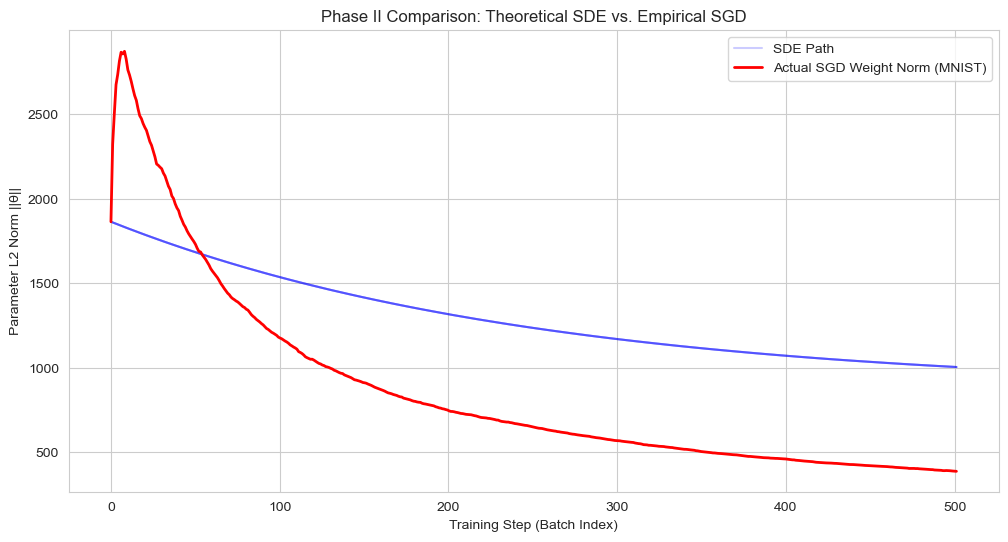

Optimal Drift (Theta): 0.0033
Optimal Diffusion (Sigma): 5.0000


In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor
from sklearn.linear_model import SGDClassifier
from sklearn.pipeline import Pipeline
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from scipy.optimize import minimize

# --- 1. SDE Simulator (Mathematical Model) ---
class SDESimulator:
    def __init__(self, drift_func, diffusion_func, paths, points, T=1.0, X0=0.0):
        self.drift_func = drift_func
        self.diffusion_func = diffusion_func
        self.paths = paths
        self.points = points
        self.T = T
        self.X0 = X0
        self.dt = T / (points - 1)
        self.t_axis = np.linspace(0, T, points)

    def simulate(self):
        X = np.zeros((self.paths, self.points))
        X[:, 0] = self.X0
        dW = np.random.normal(0, np.sqrt(self.dt), (self.paths, self.points - 1))
        
        for i in range(self.points - 1):
            # Euler-Maruyama update
            X[:, i+1] = X[:, i] + \
                        self.drift_func(X[:, i], self.t_axis[i]) * self.dt + \
                        self.diffusion_func(X[:, i], self.t_axis[i]) * dW[:, i]
        return X

# --- 2. Classical SGD Training (Empirical Model) ---
def run_sgd_comparison():
    # Setup Data
    transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
    train_set = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
    train_loader = DataLoader(train_set, batch_size=64, shuffle=True)

    pipeline = Pipeline([
        ("Scaler", StandardScaler()),
        ("sgd_classifier", SGDClassifier(loss='log_loss', random_state=42, warm_start=True))
    ])

    classes = np.arange(10)
    weight_norms = []
    
    print("Starting SGD Training...")
    # We'll limit to 500 batches for a clear comparison plot
    for batch_idx, (images, labels) in enumerate(train_loader):
        if batch_idx > 500: break
        
        images_np = images.view(images.size(0), -1).numpy()
        labels_np = labels.numpy()

        if batch_idx == 0:
            pipeline.named_steps['sgd_classifier'].partial_fit(images_np, labels_np, classes=classes)
        else:
            pipeline.named_steps['sgd_classifier'].partial_fit(images_np, labels_np)

        # Track the L2 norm of the weights to see "Diffusion"
        weights = pipeline.named_steps['sgd_classifier'].coef_
        weight_norms.append(np.linalg.norm(weights))

    print("Training finished.")
    return np.array(weight_norms)

# --- 3. Execution and Plotting ---
if __name__ == '__main__':
    # A. Run Empirical SGD
    sgd_trajectory = run_sgd_comparison()

    # B. Run SDE Simulation (Modeling the SGD norm evolution)
    # We use Ornstein-Uhlenbeck parameters to mimic weight decay/convergence
    theta_mu = 2.0  # Speed of reversion
    sigma_noise = 0.5  # Volatility of gradients
    
    drift = lambda x, t: -theta_mu * (x - np.mean(sgd_trajectory))
    diffusion = lambda x, t: sigma_noise
    
    sim = SDESimulator(drift, diffusion, paths=5, points=len(sgd_trajectory), T=1.0, X0=sgd_trajectory[0])
    sde_paths = sim.simulate()

    # C. Plot Comparison
    plt.figure(figsize=(12, 6))
    sns.set_style("whitegrid")
    
    # Plot SDE mathematical paths
    time_axis = np.linspace(0, len(sgd_trajectory), len(sgd_trajectory))
    for i in range(sde_paths.shape[0]):
        plt.plot(time_axis, sde_paths[i, :], color='blue', alpha=0.2, label='SDE Path' if i==0 else "")
    
    # Plot real SGD weight behavior
    plt.plot(time_axis, sgd_trajectory, color='red', lw=2, label='Actual SGD Weight Norm (MNIST)')
    
    plt.title("Phase II Comparison: Theoretical SDE vs. Empirical SGD")
    plt.xlabel("Training Step (Batch Index)")
    plt.ylabel("Parameter L2 Norm ||θ||")
    plt.legend()
    plt.show()

    def estimate_sde_parameters(sgd_trajectory, dt=1.0):
        """
        Fits an Ornstein-Uhlenbeck SDE to the observed SGD trajectory.
        dX_t = theta * (mu - X_t) * dt + sigma * dW_t
        """
        X = sgd_trajectory
        mu_target = np.mean(X[-100:]) # Assume the last 100 steps are "steady state"
        
        def objective(params):
            theta, sigma = params
            if theta <= 0 or sigma <= 0: return 1e9
            
            # Calculate the theoretical transitions
            # For OU process: E[X_{t+1}] = X_t + theta * (mu - X_t) * dt
            predicted_diff = theta * (mu_target - X[:-1]) * dt
            actual_diff = np.diff(X)
            
            # Mean Squared Error of the Drift
            drift_error = np.mean((actual_diff - predicted_diff)**2)
            
            # Residual variance should match sigma^2 * dt
            residual_var = np.var(actual_diff - predicted_diff)
            diffusion_error = (residual_var - (sigma**2 * dt))**2
            
            return drift_error + diffusion_error

        # Initial guess: theta=1.0, sigma=0.1
        res = minimize(objective, [1.0, 0.1], method='L-BFGS-B', bounds=[(1e-3, 10), (1e-3, 5)])
        return res.x, mu_target

    # --- Integration ---
    params, optimized_mu = estimate_sde_parameters(sgd_trajectory)
    opt_theta, opt_sigma = params

    print(f"Optimal Drift (Theta): {opt_theta:.4f}")
    print(f"Optimal Diffusion (Sigma): {opt_sigma:.4f}")

    # Re-run simulation with these "Physical" constants
    drift_opt = lambda x, t: opt_theta * (optimized_mu - x)
    diff_opt = lambda x, t: opt_sigma
    sim_opt = SDESimulator(drift_opt, diff_opt, paths=20, points=len(sgd_trajectory), X0=sgd_trajectory[0])
    X_opt = sim_opt.simulate()